# Trilytics Submission by Anal-ysts

Things are explained along the way, (at least we've tried to) and it's quite detailed so brace yourselves

In [666]:
# ===============================
# STEP 1: Import Libraries & Load Data
# ===============================

# Basic Data Handling
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [668]:
# Load Dataset
df=pd.read_excel(r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx", sheet_name="TrainData")

change the location of excel file as per your system.

In [670]:
# View structure
print("Data shape:", df.shape)
df.head()

Data shape: (47970, 105)


,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,Address type,Ownership,No_of_Active_Loan_In_Bureau,Avg_Disbursement_Amount_Bureau,Non_Agriculture_Income,Total_Land_For_Agriculture,"K022-Village category based on Agri parameters (Good, Average, Poor)",K022-Nearest Mandi Name,K022-Proximity to nearest mandi (Km),K022-Proximity to nearest railway (Km),KO22-Village score based on socio-economic parameters (0 to 100),"K022-Village category based on socio-economic parameters (Good, Average, Poor)",K022-Seasonal Average Rainfall (mm),K022-Ambient temperature (min & max),"R022-Village category based on Agri parameters (Good, Average, Poor)",R022-Seasonal Average Rainfall (mm),R022-Ambient temperature (min & max),K021-Seasonal Average Rainfall (mm),K021-Ambient temperature (min & max),R021-Seasonal Average Rainfall (mm),R021-Ambient temperature (min & max),R020-Seasonal Average Rainfall (mm),R020-Ambient temperature (min & max),Perc_of_house_with_6plus_room,Women_15_19_Mothers_or_Pregnant_at_time_of_survey,perc_of_pop_living_in_hh_electricity,perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,mat_roof_Metal_GI_Asbestos_sheets,perc_of_Wall_material_with_Burnt_brick,Households_with_improved_Sanitation_Facility,perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k,K022-Total Geographical Area (in Hectares)-,K022-Net Agri area (in Ha)-,K022-Net Agri area (% of total geog area)-,Kharif Seasons Irrigated area in 2022,Kharif Seasons Cropping density in 2022,Kharif Seasons Agricultural performance in 2022,Kharif Seasons Agricultural Score in 2022,Kharif Seasons Type of soil in 2022,Kharif Seasons Type of water bodies in hectares 2022,Kharif Seasons Agro Ecological Sub Zone in 2022,Kharif Seasons Seasonal average groundwater thickness (cm) in 2022,Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2022,Rabi Seasons Season Irrigated area in 2022,Rabi Seasons Cropping density in 2022,Rabi Seasons Agricultural performance in 2022,Rabi Seasons Agricultural Score in 2022,Rabi Seasons Type of soil in 2022,Rabi Seasons Type of water bodies in hectares 2022,Rabi Seasons Agro Ecological Sub Zone in 2022,Rabi Seasons Seasonal average groundwater thickness (cm) in 2022,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022,Rabi Seasons Kharif Season Irrigated area in 2021,Rabi Seasons Cropping density in 2021,Rabi Seasons Agricultural performance in 2021,Rabi Seasons Agricultural Score in 2021,Rabi Seasons Type of soil in 2021,Rabi Seasons Type of water bodies in hectares 2021,Rabi Seasons Agro Ecological Sub Zone in 2021,Rabi Seasons Seasonal average groundwater thickness (cm) in 2021,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021,Kharif Seasons Kharif Season Irrigated area in 2021,Kharif Seasons Cropping density in 2021,Kharif Seasons Agricultural performance in 2021,Kharif Seasons Agricultural Score in 2021,Kharif Seasons Type of soil in 2021,Kharif Seasons Type of water bodies in hectares 2021,Kharif Seasons Agro Ecological Sub Zone in 2021,Kharif Seasons Seasonal average groundwater thickness (cm) in 2021,Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021,Kharif Seasons Kharif Season Irrigated area in 2020,Kharif Seasons Cropping density in 2020,Kharif Seasons Agricultural performance in 2020,Kharif Seasons Agricultural Score in 2020,Kharif Seasons Type of soil in 2020,Kharif Seasons Type of water bodies in hectares 2020,Kharif Seasons Agro Ecological Sub Zone in 2020,Kharif Seasons Seasonal average groundwater thickness (cm) in 2020,Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Rabi Seasons Kharif Season Irrigated area in 2020,Rabi Seasons Cropping density in 2020,Rabi Seasons Agricultural performance in 2020,Rabi Seasons Agricultural Score in 2020,Rabi Seasons Type of soil in 2020,Rabi Seasons Type of water bodies in hectares 2020,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi 

In [671]:
# ===============================
# STEP 2: Clean & Standardize Column Names
# ===============================

def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

# Apply to all column names
df.columns = [clean_column(col) for col in df.columns]

# Preview cleaned column names
print("Cleaned Column Names:\n")
print(df.columns.tolist()[:15])  # Show first 15 as a sample


Cleaned Column Names:

['farmerid', 'state', 'region', 'sex', 'city', 'zipcode', 'district', 'village', 'marital_status', 'location', 'address_type', 'ownership', 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income']


In [672]:
# ===============================
# STEP 4.5: Save Cleaned Dataset (Optional)
# ===============================

df.to_csv("cleaned_farmer_income_data.csv", index=False)
print("Cleaned dataset saved as cleaned_farmer_income_data.csv ✅")


Cleaned dataset saved as cleaned_farmer_income_data.csv ✅


In [673]:
# ===============================
# STEP 3: Missing Value Analysis
# ===============================

# Total missing values per column
missing_counts = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing_counts / len(df)) * 100

# Combine into a summary table
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})

# Filter only those with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

print("Columns with missing values:\n")
missing_df.head(15)


Columns with missing values:



,Missing Count,Missing %
avg_disbursement_amount_bureau,20790,43.339587
location,17030,35.501355
address_type,17030,35.501355
ownership,17030,35.501355
perc_of_house_with_6plus_room,168,0.350219
women_15_19_mothers_or_pregnant_at_time_of_survey,168,0.350219
perc_of_pop_living_in_hh_electricity,168,0.350219
perc_households_with_pucca_house_that_has_more_than_3_rooms,168,0.350219
mat_roof_metal_gi_asbestos_sheets,168,0.350219
perc_of_wall_material_with_burnt_brick,168,0.350219


In [674]:
# there are only 13 columns that have missing values in them.

In [675]:
# ===============================
# STEP 4: Handling Missing Values
# ===============================
df[['location', 'address_type', 'ownership']] = df[['location', 'address_type', 'ownership']].fillna("missing_info")


Avg Disbursement Amount: Missing values were filled with 0, assuming absence of formal credit history — common in rural India where loans may be taken from untracked sources like relatives or local lenders.

Additionally, we created a binary feature has_bureau_data to indicate the presence of bureau records and preserve the original signal.

In [677]:
# Dealing with Avg Disbursement Amt, missing values

# Step 1: Create a binary flag indicating presence of bureau loan data
df['has_loan_bureau_data'] = df['avg_disbursement_amount_bureau'].notna().astype(int)

# Step 2: Replace missing values in Avg_Disbursement_Amount_Bureau with 0
# (Alternatively, you could use -1 to make "missing" more explicit numerically)
df['avg_disbursement_amount_bureau'] = df['avg_disbursement_amount_bureau'].fillna(0)

# Optional: View distribution for sanity check
print(df[['avg_disbursement_amount_bureau', 'has_loan_bureau_data']].head(10))


   avg_disbursement_amount_bureau  has_loan_bureau_data
0                        0.000000                     0
1                    74000.000000                     1
2                   232999.857143                     1
3                        0.000000                     0
4                   138203.000000                     1
5                        0.000000                     0
6                        0.000000                     0
7                        0.000000                     0
8                   100000.000000                     1
9                    66187.000000                     1


In [678]:
# Count of numeric columns
num_numeric = len(df.select_dtypes(include='number').columns)

# Count of non-numeric columns
num_non_numeric = len(df.select_dtypes(exclude='number').columns)


print('number of num columns',num_numeric)
print('number of non num columns',num_non_numeric)


number of num columns 68
number of non num columns 38


We did encoding in some columns to deal with non numeric columns

Label Encoding:
Applied to categorical columns with low cardinality (e.g., region, sex, ownership). This replaces each category with a numeric label. Chosen for tree-based models that can handle arbitrary label values without assuming order.

Target Encoding:
Used for higher-cardinality categorical columns where label encoding could inject noise. Each category was replaced with the mean target income for that group, capturing direct statistical relationships.

KNN Imputer:
Used to fill missing values in selected numeric columns by averaging values from the nearest neighbors. This preserves patterns in the data better than simple mean/median imputation.

In [680]:
# ===============================
# STEP X: Normalize & KNN Impute
# ===============================

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# 🔹 Define columns to use for KNN input
knn_input_columns = [
    'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income',
    'k022_proximity_to_nearest_mandi_km', 'k022_proximity_to_nearest_railway_km',
    'ko22_village_score_based_on_socio_economic_parameters_0_to_100',
    'k022_seasonal_average_rainfall_mm', 'r022_seasonal_average_rainfall_mm',
    'k021_seasonal_average_rainfall_mm', 'r021_seasonal_average_rainfall_mm',
    'r020_seasonal_average_rainfall_mm', 'k022_total_geographical_area_in_hectares_',
    'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_',
    'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022',
    'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022',
    'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022',
    'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022',
    'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022',
    'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022',
    'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022',
    'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022',
    'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021',
    'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021',
    'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021',
    'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021',
    'kharif_seasons_kharif_season_irrigated_area_in_2021', 'kharif_seasons_cropping_density_in_2021',
    'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021',
    'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021',
    'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021',
    'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020',
    'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020',
    'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020',
    'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020',
    'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020',
    'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020',
    'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020',
    'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020',
    'night_light_index', 'village_score_based_on_socio_economic_parameters_non_normalised',
    'village_score_based_on_socio_economic_parameters_0_to_100',
    'land_holding_index_source_total_agri_area__no_of_people',
    'road_density_km__sqkm'
]

# 🔹 Define columns that have missing values and need to be imputed
knn_target_columns = [
    'perc_of_house_with_6plus_room', 'women_15_19_mothers_or_pregnant_at_time_of_survey',
    'perc_of_pop_living_in_hh_electricity', 'perc_households_with_pucca_house_that_has_more_than_3_rooms',
    'mat_roof_metal_gi_asbestos_sheets', 'perc_of_wall_material_with_burnt_brick',
    'households_with_improved_sanitation_facility', 'perc_households_do_not_have_kcc_with_the_credit_limit_of_50k',
    'total_land_for_agriculture'
]

# 🔹 Combine both to apply scaler and imputer
all_knn_columns = knn_input_columns + knn_target_columns

# 🔹 Subset the data
knn_df = df[all_knn_columns].copy()

# 🔹 Normalize
scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_df)

# 🔹 Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

# 🔹 Convert back to DataFrame
knn_imputed_df = pd.DataFrame(knn_imputed, columns=all_knn_columns)

# 🔹 Update only the target columns in the original df
df[knn_target_columns] = knn_imputed_df[knn_target_columns]

print("✅ KNN imputation completed for selected columns.")


✅ KNN imputation completed for selected columns.


In [681]:
df.to_csv("cleaned_knn_imputed_data.csv", index=False)


In [682]:
# Save the KNN Imputer for Later (e.g., for test data)
import joblib

joblib.dump(scaler, 'scaler_knn_imputer.pkl')
joblib.dump(imputer, 'knn_imputer.pkl')


['knn_imputer.pkl']

In [683]:
# Checking for column values similarity to remove similar columns
col_list=[ 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income', 'total_land_for_agriculture', 'k022_nearest_mandi_name', 'k022_proximity_to_nearest_mandi_km', 'ko22_village_score_based_on_socio_economic_parameters_0_to_100', 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor', 'k022_seasonal_average_rainfall_mm', 'k022_ambient_temperature_min_&_max', 'r022_village_category_based_on_agri_parameters_good,_average,_poor', 'r022_seasonal_average_rainfall_mm', 'r022_ambient_temperature_min_&_max', 'k021_seasonal_average_rainfall_mm', 'k021_ambient_temperature_min_&_max', 'r021_seasonal_average_rainfall_mm', 'r021_ambient_temperature_min_&_max', 'r020_seasonal_average_rainfall_mm', 'r020_ambient_temperature_min_&_max', 'k022_total_geographical_area_in_hectares_', 'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_', 'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022', 'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022', 'kharif_seasons__type_of_soil_in_2022', 'kharif_seasons__type_of_water_bodies_in_hectares_2022', 'kharif_seasons__agro_ecological_sub_zone_in_2022', 'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022', 'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022', 'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022', 'rabi_seasons_type_of_soil_in_2022', 'rabi_seasons_type_of_water_bodies_in_hectares_2022', 'rabi_seasons_agro_ecological_sub_zone_in_2022', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021', 'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021', 'rabi_seasons_type_of_soil_in_2021', 'rabi_seasons_type_of_water_bodies_in_hectares_2021', 'rabi_seasons_agro_ecological_sub_zone_in_2021', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2021', 'kharif_seasons_cropping_density_in_2021', 'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021', 'kharif_seasons_type_of_soil_in_2021', 'kharif_seasons_type_of_water_bodies_in_hectares_2021', 'kharif_seasons_agro_ecological_sub_zone_in_2021', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020', 'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020', 'kharif_seasons_type_of_soil_in_2020', 'kharif_seasons_type_of_water_bodies_in_hectares_2020', 'kharif_seasons_agro_ecological_sub_zone_in_2020', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020', 'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020', 'rabi_seasons_type_of_soil_in_2020', 'rabi_seasons_type_of_water_bodies_in_hectares_2020', 'rabi_seasons_agro_ecological_sub_zone_in_2020', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'village_score_based_on_socio_economic_parameters_non_normalised', 'village_score_based_on_socio_economic_parameters_0_to_100', 'village_category_based_on_socio_economic_parameters_good,_average,_poor'] 

In [684]:
def check_all_column_similarities(df, col_list=None, threshold=0.95, include_self=False):
    
    from itertools import combinations_with_replacement, combinations
    import pandas as pd
    
    # Use all columns if col_list is not provided
    if col_list is None:
        col_list = df.columns.tolist()
    
    # Validate columns exist in DataFrame
    missing_cols = [col for col in col_list if col not in df.columns]
    if missing_cols:
        print(f"⚠️  Warning: These columns don't exist in DataFrame: {missing_cols}")
        col_list = [col for col in col_list if col in df.columns]
    
    if len(col_list) < 2:
        print("❌ Need at least 2 valid columns to compare")
        return {}
    
    results = {}
    total_comparisons = 0
    high_similarity_count = 0
    
    print(f"🔍 Checking similarity between {len(col_list)} columns...")
    print(f"📊 Threshold: {threshold * 100:.1f}%")
    print("-" * 80)
    
    # Choose iteration method based on include_self parameter
    if include_self:
        column_pairs = combinations_with_replacement(col_list, 2)
    else:
        column_pairs = combinations(col_list, 2)
    
    for col1, col2 in column_pairs:
        total_comparisons += 1
        
        # Handle case where both columns are the same (only if include_self=True)
        if col1 == col2:
            similarity = 1.0
        else:
            # Get valid (non-null) mask for both columns
            valid_mask = df[col1].notnull() & df[col2].notnull()
            valid_count = valid_mask.sum()
            
            if valid_count == 0:
                similarity = 0.0
                print(f"⚠️  {col1} vs {col2} → No valid data to compare")
                continue
            else:
                # Calculate similarity only on valid data
                similarity = (df[col1] == df[col2])[valid_mask].mean()
        
        similarity = round(similarity, 4)
        
        # Store and print results that meet threshold
        if similarity >= threshold:
            high_similarity_count += 1
            pair_key = f"{col1} vs {col2}"
            results[pair_key] = similarity
            
            # Enhanced output with more details
            valid_count = (df[col1].notnull() & df[col2].notnull()).sum() if col1 != col2 else len(df)
            total_rows = len(df)
            
            print(f"✅ {col1} vs {col2}")
            print(f"   📈 Similarity: {similarity * 100:.2f}%")
            print(f"   📋 Valid comparisons: {valid_count}/{total_rows} rows")
            print()
    
    # Summary statistics
    print("-" * 80)
    print(f"📊 SUMMARY:")
    print(f"   Total comparisons made: {total_comparisons}")
    print(f"   High similarity pairs found: {high_similarity_count}")
    print(f"   Percentage of high similarity pairs: {(high_similarity_count/total_comparisons)*100:.1f}%")
    
    if results:
        print(f"\n🏆 TOP SIMILAR PAIRS:")
        sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
        for i, (pair, sim) in enumerate(sorted_results[:5], 1):
            print(f"   {i}. {pair}: {sim*100:.2f}%")
    else:
        print(f"❌ No column pairs found with similarity >= {threshold*100:.1f}%")
    
    return results

In [685]:
def check_all_column_similarities(df, col_list=None, threshold=0.95, include_self=False):
    
    from itertools import combinations_with_replacement, combinations
    import pandas as pd
    
    # Use all columns if col_list is not provided
    if col_list is None:
        col_list = df.columns.tolist()
    
    # Validate columns exist in DataFrame
    missing_cols = [col for col in col_list if col not in df.columns]
    if missing_cols:
        print(f"⚠️  Warning: These columns don't exist in DataFrame: {missing_cols}")
        col_list = [col for col in col_list if col in df.columns]
    
    if len(col_list) < 2:
        print("❌ Need at least 2 valid columns to compare")
        return {}
    
    results = {}
    total_comparisons = 0
    high_similarity_count = 0
    
    print(f"🔍 Checking similarity between {len(col_list)} columns...")
    print(f"📊 Threshold: {threshold * 100:.1f}%")
    print("-" * 80)
    
    # Choose iteration method based on include_self parameter
    if include_self:
        column_pairs = combinations_with_replacement(col_list, 2)
    else:
        column_pairs = combinations(col_list, 2)
    
    for col1, col2 in column_pairs:
        total_comparisons += 1
        
        # Handle case where both columns are the same (only if include_self=True)
        if col1 == col2:
            similarity = 1.0
        else:
            # Get valid (non-null) mask for both columns
            valid_mask = df[col1].notnull() & df[col2].notnull()
            valid_count = valid_mask.sum()
            
            if valid_count == 0:
                similarity = 0.0
                print(f"⚠️  {col1} vs {col2} → No valid data to compare")
                continue
            else:
                # Calculate similarity only on valid data
                similarity = (df[col1] == df[col2])[valid_mask].mean()
        
        similarity = round(similarity, 4)
        
        # Store and print results that meet threshold
        if similarity >= threshold:
            high_similarity_count += 1
            pair_key = f"{col1} vs {col2}"
            results[pair_key] = similarity
            
            # Enhanced output with more details
            valid_count = (df[col1].notnull() & df[col2].notnull()).sum() if col1 != col2 else len(df)
            total_rows = len(df)
            
            print(f"✅ {col1} vs {col2}")
            print(f"   📈 Similarity: {similarity * 100:.2f}%")
            print(f"   📋 Valid comparisons: {valid_count}/{total_rows} rows")
            print()
    
    # Summary statistics
    print("-" * 80)
    print(f"📊 SUMMARY:")
    print(f"   Total comparisons made: {total_comparisons}")
    print(f"   High similarity pairs found: {high_similarity_count}")
    print(f"   Percentage of high similarity pairs: {(high_similarity_count/total_comparisons)*100:.1f}%")
    
    if results:
        print(f"\n🏆 TOP SIMILAR PAIRS:")
        sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
        for i, (pair, sim) in enumerate(sorted_results[:5], 1):
            print(f"   {i}. {pair}: {sim*100:.2f}%")
    else:
        print(f"❌ No column pairs found with similarity >= {threshold*100:.1f}%")
    
    return results

In [686]:
check_all_column_similarities(df,col_list,0.95)

🔍 Checking similarity between 79 columns...
📊 Threshold: 95.0%
--------------------------------------------------------------------------------
✅ ko22_village_score_based_on_socio_economic_parameters_0_to_100 vs village_score_based_on_socio_economic_parameters_0_to_100
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ k022_village_category_based_on_socio_economic_parameters_good,_average,_poor vs village_category_based_on_socio_economic_parameters_good,_average,_poor
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2022
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2021
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_seasons__type_of_soil_in_2022 vs kharif_seasons_type_of_soil_in_2021
   📈 Similarity: 100.00%
   📋 Valid comparisons: 47970/47970 rows

✅ kharif_se

{'ko22_village_score_based_on_socio_economic_parameters_0_to_100 vs village_score_based_on_socio_economic_parameters_0_to_100': 1.0,
 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor vs village_category_based_on_socio_economic_parameters_good,_average,_poor': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2022': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2021': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs kharif_seasons_type_of_soil_in_2021': 1.0,
 'kharif_seasons__type_of_soil_in_2022 vs rabi_seasons_type_of_soil_in_2020': 1.0,
 'kharif_seasons__type_of_water_bodies_in_hectares_2022 vs rabi_seasons_type_of_water_bodies_in_hectares_2022': 1.0,
 'kharif_seasons__type_of_water_bodies_in_hectares_2022 vs rabi_seasons_type_of_water_bodies_in_hectares_2021': 1.0,
 'kharif_seasons__type_of_water_bodies_in_hectares_2022 vs kharif_seasons_type_of_water_bodies_in_hectares_2021': 1.0,
 'kharif_seasons__t

In [687]:
# columns to drop as they have same values throughout

drop_col = ['kharif_seasons_cropping_density_in_2021', 
            'village_score_based_on_socio_economic_parameters_0_to_100', 
            'rabi_seasons_type_of_soil_in_2021', 'kharif_seasons__type_of_soil_in_2022', 
            'rabi_seasons_type_of_soil_in_2022', 'kharif_seasons_type_of_soil_in_2020',
            'rabi_seasons_agro_ecological_sub_zone_in_2020', 'rabi_seasons_type_of_soil_in_2020', 
            'rabi_seasons_type_of_water_bodies_in_hectares_2021', 
            'rabi_seasons_type_of_water_bodies_in_hectares_2022', 
            'rabi_seasons_agro_ecological_sub_zone_in_2021', 
            'rabi_seasons_type_of_water_bodies_in_hectares_2020', 
            'kharif_seasons_kharif_season_irrigated_area_in_2021', 
            'kharif_seasons_type_of_water_bodies_in_hectares_2021',
            'kharif_seasons_type_of_water_bodies_in_hectares_2020',
            'kharif_seasons_agro_ecological_sub_zone_in_2021' ,
            'kharif_seasons_agro_ecological_sub_zone_in_2021' ,
            'rabi_seasons_agro_ecological_sub_zone_in_2022',
           'kharif_seasons_agro_ecological_sub_zone_in_2020']

In [688]:
# In addition to the above list, some columns are just increasing the noise in the data, such as
# zipcode, location, etc and some other are just repeating the data already given in numeric form. 
# So they are to be dropped.

In [689]:
columns_to_be_dropped = ['zipcode','location','city','village',
                         'r022_village_category_based_on_agri_parameters_good,_average,_poor',
                         'k022_village_category_based_on_agri_parameters_good,_average,_poor',
                         'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor',
                         'village_category_based_on_socio_economic_parameters_good,_average,_poor']
drop_col.extend(columns_to_be_dropped)

In [690]:
df.drop(columns=drop_col, inplace=True)

In [691]:
# Now let's deal with water bodies, we are converting them to binary flags

In [692]:
# First, replace missing/None-like values with empty string
df['kharif_seasons__type_of_water_bodies_in_hectares_2022'] = df['kharif_seasons__type_of_water_bodies_in_hectares_2022'].fillna("").astype(str).str.lower()

# Define keywords to look for
keywords = ['river', 'water', 'reservoir', 'riverbank', 'wetland']

# Create binary columns for each keyword
for kw in keywords:
    df[f'near_{kw}'] = df['kharif_seasons__type_of_water_bodies_in_hectares_2022'].apply(lambda x: int(kw in x))

# Optional: Drop the original column
df.drop(columns=['kharif_seasons__type_of_water_bodies_in_hectares_2022'], inplace=True)

# Preview
df[[f'near_{kw}' for kw in keywords]].head()


,near_river,near_water,near_reservoir,near_riverbank,near_wetland
0,0,1,0,0,0
1,0,1,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [693]:
# Replace with actual column names
temp_cols = [
    'k022_ambient_temperature_min_&_max',
    'r022_ambient_temperature_min_&_max',
    'k021_ambient_temperature_min_&_max',
    'r021_ambient_temperature_min_&_max',
    'r020_ambient_temperature_min_&_max'
]

for col in temp_cols:
    df[[f"{col}_min", f"{col}_max"]] = df[col].str.split('/', expand=True).astype(float)


In [694]:
df.drop(columns=temp_cols, inplace=True)


In [790]:
import joblib

# Your label columns (make sure these match training)
label_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021'
]

from sklearn.preprocessing import LabelEncoder

# Create dictionary of fitted encoders
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Fit on training data
    label_encoders[col] = le

# Save the dictionary of encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

print(f"✅ Saved {len(label_encoders)} label encoders to 'label_encoders.pkl'")


✅ Saved 7 label encoders to 'label_encoders.pkl'


In [696]:
# target encoding for high cardinality columns, namely:
# 'district':405, 'k022_nearest_mandi_name':890, 'state':17 

In [697]:
def target_encode_cv(df, col, target, n_splits=5, seed=42):
    df = df.copy()
    df[col + '_target_enc'] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    for train_idx, val_idx in kf.split(df):
        train, val = df.iloc[train_idx], df.iloc[val_idx]
        mapping = train.groupby(col)[target].mean()
        df.loc[df.index[val_idx], col + '_target_enc'] = val[col].map(mapping)
    
    # Safe assignment to avoid chained assignment warning
    global_mean = df[target].mean()
    df[col + '_target_enc'] = df[col + '_target_enc'].fillna(global_mean)
    
    return df


In [699]:
from sklearn.model_selection import KFold

for col in ['district', 'k022_nearest_mandi_name', 'state']:
    df = target_encode_cv(df, col, target='target_variable_total_income')
    
target_encoding_maps = {}
for col in ['district', 'k022_nearest_mandi_name', 'state']:
    mapping = df.groupby(col)['target_variable_total_income'].mean().to_dict()
    target_encoding_maps[col] = mapping

global_mean = df['target_variable_total_income'].mean()

In [700]:
import joblib

# Dictionary to hold mapping used for target encoding
target_maps = {}

# These are the columns you target encoded
target_encoded_cols = ['district', 'k022_nearest_mandi_name', 'state']

# Save the mapping used during training
for col in target_encoded_cols:
    mapping = df.groupby(col)['target_variable_total_income'].mean().to_dict()
    target_maps[col] = mapping

# Save to file
joblib.dump(target_maps, "target_maps.pkl")
print("✅ target_maps.pkl saved.")


✅ target_maps.pkl saved.


In [701]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error
import numpy as np

# Label-encoded columns (low cardinality)
label_encoded_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021'
]

# Target-encoded columns (high cardinality)
target_encoded_cols = [
    'district_target_enc', 
    'k022_nearest_mandi_name_target_enc', 
    'state_target_enc'
]

# Full list of encoded columns
encoded_cols = label_encoded_cols + target_encoded_cols

# # Define features and target
# X = df[encoded_cols]
# y = df['target_variable_total_income']


# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Drop target and irrelevant ID
num_cols = [col for col in num_cols if col not in ['farmerid', 'target_variable_total_income']]

# Final feature set
X_full = df[num_cols + encoded_cols]
y = df['target_variable_total_income']


# Define scoring metric
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Cross-validation score
scores = cross_val_score(LinearRegression(), X_full, y, cv=5, scoring=mae_scorer)

print("Cross-validated MAE scores (negative):", scores)
print("Average MAE:", -np.mean(scores))


Cross-validated MAE scores (negative): [-328188.61699979 -322507.51699254 -301952.51647185 -445586.2148531
 -386880.13048449]
Average MAE: 357022.999160354


In [702]:
df['target_variable_total_income'].describe()

count    4.797000e+04
mean     1.222255e+06
std      2.073935e+06
min      2.900000e+04
25%      7.200000e+05
50%      9.500000e+05
75%      1.295000e+06
max      8.000000e+07
Name: target_variable_total_income, dtype: float64

In [703]:
avg_income = df['target_variable_total_income'].mean()
print("MAE as % of Avg Income:", (356990 / avg_income) * 100)


MAE as % of Avg Income: 29.207481111875694


In [704]:
#  Some engineered Features 
# ===============================
# 1. Relative Income Features
# ===============================
for geo in ['state', 'region', 'district']:
    avg_col = f'avg_income_by_{geo}'
    bin_col = f'above_avg_{geo}_income'

    df[avg_col] = df.groupby(geo)['target_variable_total_income'].transform('mean')
    df[bin_col] = (df['target_variable_total_income'] > df[avg_col]).astype(int)

# ===============================
# 2. Domain-Inspired Features
# ===============================

# Land-based
df['land_per_active_loan'] = df['total_land_for_agriculture'] / (df['no_of_active_loan_in_bureau'] + 1)
df['agri_income_ratio'] = df['target_variable_total_income'] / (df['non_agriculture_income'] + 1)

# Rainfall
rain_cols = [col for col in df.columns if 'rainfall_mm' in col]
df['avg_rainfall'] = df[rain_cols].mean(axis=1)

# Living conditions
df['housing_quality_score'] = (
    df['perc_of_house_with_6plus_room'] +
    df['perc_households_with_pucca_house_that_has_more_than_3_rooms'] +
    df['perc_of_pop_living_in_hh_electricity']
) / 3

# Groundwater
gw_cols = [col for col in df.columns if 'groundwater_thickness' in col]
df['groundwater_variability'] = df[gw_cols].std(axis=1)

# Market access
df['market_access_score'] = 1 / (df['k022_proximity_to_nearest_mandi_km'] + 1)
df['rail_access_score'] = 1 / (df['k022_proximity_to_nearest_railway_km'] + 1)


In [705]:
df.drop(columns=['district', 'k022_nearest_mandi_name', 'state'], inplace=True)


In [706]:
df.to_csv("cleaned_dataset.csv", index=False)


In [707]:
import joblib

# Define feature columns used for training
X = df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
feature_columns = X.columns.tolist()

# Save them for use in test preprocessing
joblib.dump(feature_columns, 'feature_columns.pkl')
print("✅ feature_columns.pkl saved.")


✅ feature_columns.pkl saved.


Some Graphs to understand the data better

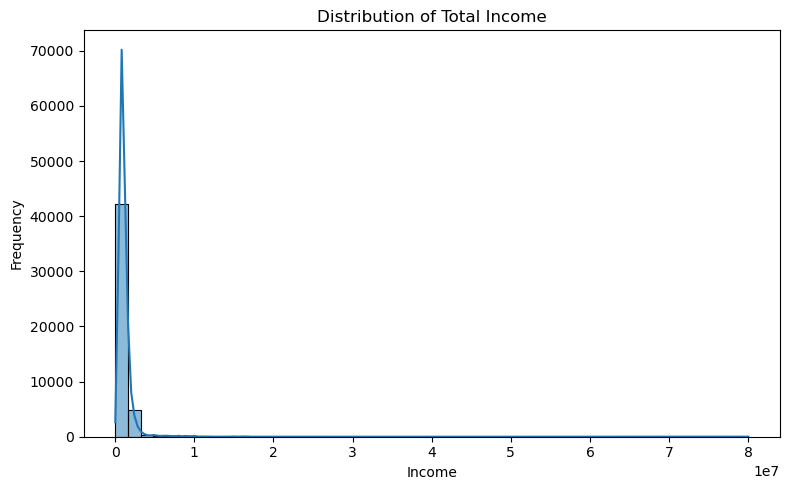

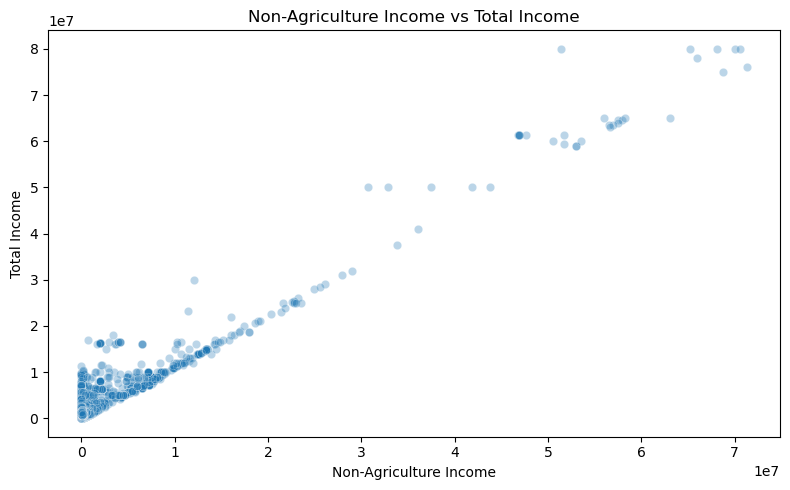

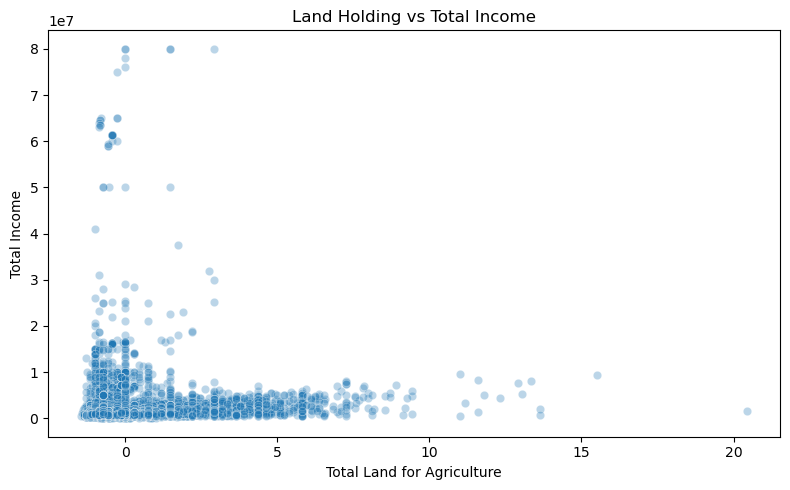

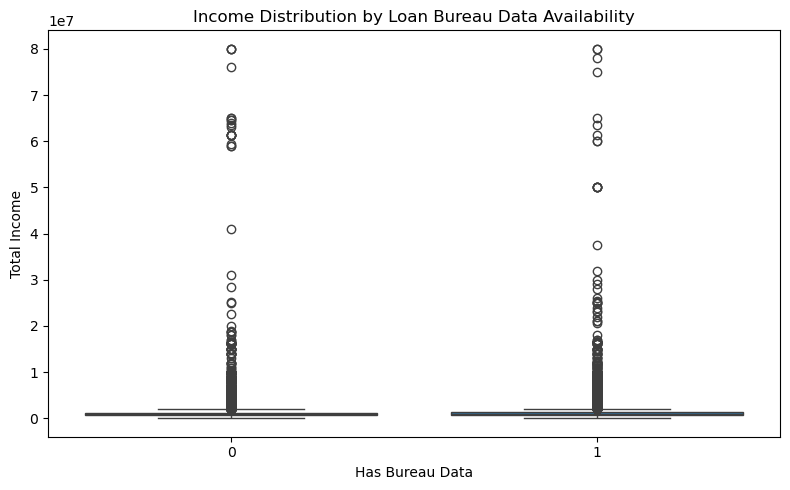

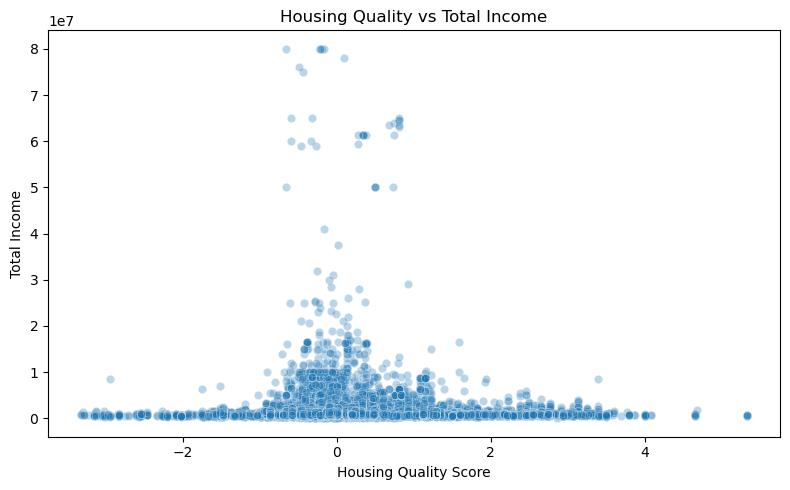

In [710]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample subset of engineered features for plotting
columns_to_plot = [
    'non_agriculture_income',
    'total_land_for_agriculture',
    'avg_disbursement_amount_bureau',
    'has_loan_bureau_data',
    'k022_seasonal_average_rainfall_mm',
    'perc_of_pop_living_in_hh_electricity',
    'mat_roof_metal_gi_asbestos_sheets',
    'housing_quality_score',
    'market_access_score',
    'agri_income_ratio',
    'target_variable_total_income'
]

# Load processed dataframe (assumes availability in context)
df = pd.read_csv(r"C:\Users\ak32a\Downloads\Anal-ysts\cleaned_dataset.csv")  # Replace with actual path if needed

# Plot 1: Distribution of Income
plt.figure(figsize=(8, 5))
sns.histplot(df['target_variable_total_income'], bins=50, kde=True)
plt.title("Distribution of Total Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot 2: Non-agriculture income vs Total Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='non_agriculture_income', y='target_variable_total_income', alpha=0.3)
plt.title("Non-Agriculture Income vs Total Income")
plt.xlabel("Non-Agriculture Income")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

# Plot 3: Total Land vs Total Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_land_for_agriculture', y='target_variable_total_income', alpha=0.3)
plt.title("Land Holding vs Total Income")
plt.xlabel("Total Land for Agriculture")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

# Plot 4: Average Disbursement Amount vs Income
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='has_loan_bureau_data', y='target_variable_total_income')
plt.title("Income Distribution by Loan Bureau Data Availability")
plt.xlabel("Has Bureau Data")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

# Plot 5: Housing Quality Score vs Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='housing_quality_score', y='target_variable_total_income', alpha=0.3)
plt.title("Housing Quality vs Total Income")
plt.xlabel("Housing Quality Score")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()


# Model Training 

### XGBoost

In [713]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

# Define features and target
X = df.drop(columns=['target_variable_total_income', 'farmerid'])  # Drop target + irrelevant ID
y = df['target_variable_total_income']

# Initialize XGBoost regressor
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Cross-validation MAE scorer
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Perform cross-validation
scores = cross_val_score(xgb_model, X, y, cv=5, scoring=mae_scorer)

print("Cross-validated MAE scores (negative):", scores)
print("Average MAE:", -np.mean(scores))


Cross-validated MAE scores (negative): [-144799.875    -132210.234375 -120447.8125   -191592.28125
 -132329.671875]
Average MAE: 144275.975


In [714]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# RMSE scorer (note: use negative MSE then take sqrt of mean later)
rmse_scores = cross_val_score(
    xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error'
)

# R2 Score
r2_scores = cross_val_score(
    xgb_model, X, y, cv=5, scoring='r2'
)

# MAPE (custom scorer)
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)
mape_scores = cross_val_score(
    xgb_model, X, y, cv=5, scoring=mape_scorer
)

print("Average MAE:", 144275.975)  # Already known
print("Average RMSE:", -np.mean(rmse_scores))
print("Average R² Score:", np.mean(r2_scores))
print("Average MAPE (%):", -np.mean(mape_scores) * 100)


Average MAE: 144275.975
Average RMSE: 989493.9375
Average R² Score: 0.7187442183494568
Average MAPE (%): 9.034213870763779


### Dealing with outliers and improving the model

In [716]:
# Investigate Outliers

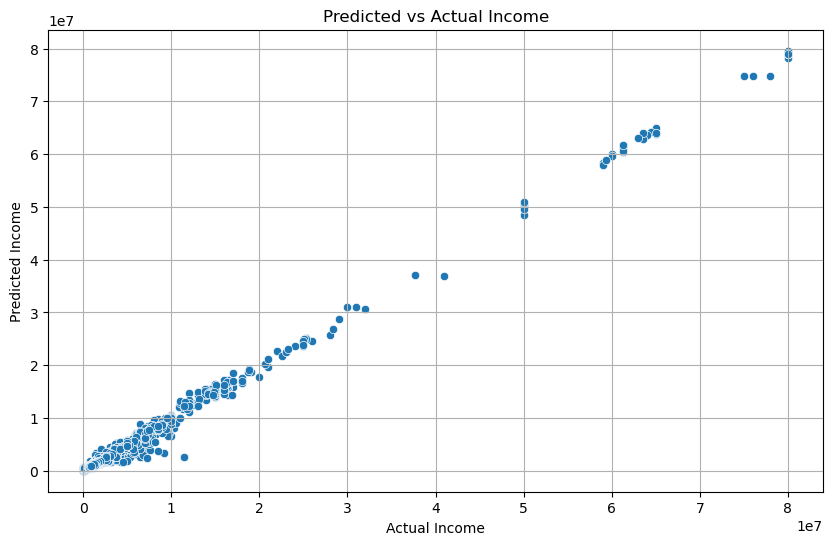

In [717]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of actual vs predicted
xgb_model.fit(X, y)
y_pred_full = xgb_model.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred_full)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs Actual Income")
plt.grid(True)
plt.show()


In [718]:
# . Feature Importance

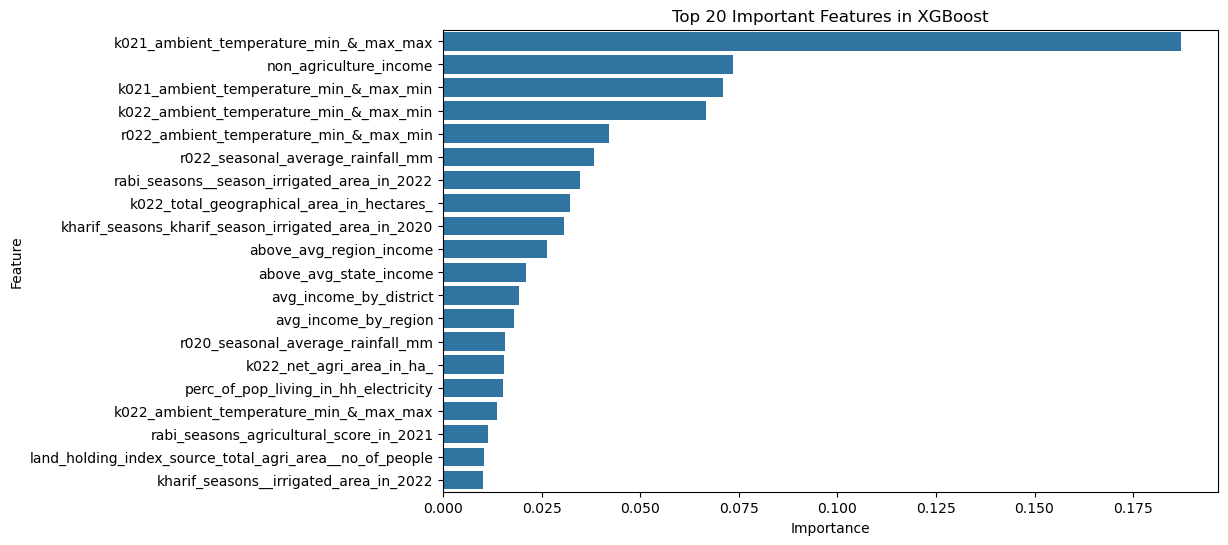

In [719]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fit final model
xgb_model.fit(X, y)

# Plot feature importances
importances = xgb_model.feature_importances_
features = X.columns

feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Top 20 Important Features in XGBoost")
plt.show()


In [720]:
# Log Transformation

In [721]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Features and log-transformed target
X = df.drop(columns=['target_variable_total_income', 'farmerid'])
y = df['target_variable_total_income']
y_log = np.log1p(y)  # log(1 + y) transformation to handle zeros

# Initialize XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Cross-validated predictions on transformed target
y_pred_log = cross_val_predict(xgb_model, X, y_log, cv=5)

# Inverse transform predictions
y_pred_original = np.expm1(y_pred_log)  # exp(y) - 1

# Evaluate using original target (not log)
mae = mean_absolute_error(y, y_pred_original)
mse = mean_squared_error(y, y_pred_original)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_original)
mape = mean_absolute_percentage_error(y, y_pred_original) * 100

# Print metrics
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")


MAE: ₹118,847.61
RMSE: ₹1,230,113.48
R² Score: 0.6482
MAPE: 5.85%


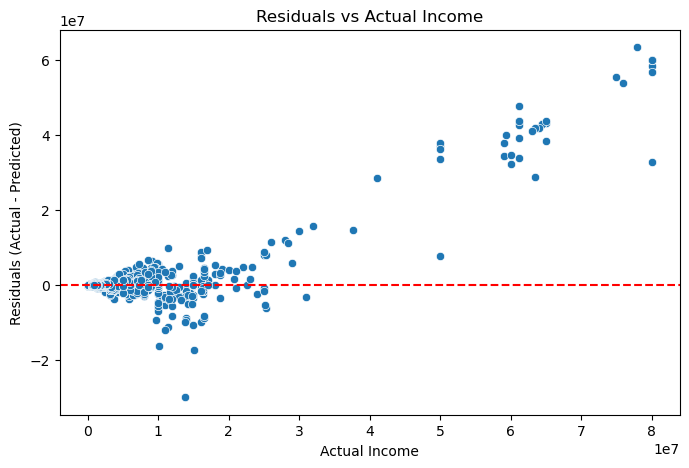

MAE by Income Bracket:
Income_Bracket
<1L        3.545735e+04
1L–10L     1.359451e+05
10L–20L    3.857888e+06
20L–40L    6.403763e+06
40L+       4.176176e+07
dtype: float64


C:\Users\ak32a\AppData\Local\Temp\ipykernel_14024\3400854542.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bracket_errors = df_eval.groupby('Income_Bracket').apply(lambda x: mean_absolute_error(x['Actual'], x['Predicted']))
C:\Users\ak32a\AppData\Local\Temp\ipykernel_14024\3400854542.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bracket_errors = df_eval.groupby('Income_Bracket').apply(lambda x: mean_absolute_error(x['Actual'], x['Predicted']))


In [722]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Residuals
residuals = y - y_pred_original

# 1. Residuals vs Actual Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Actual Income")
plt.xlabel("Actual Income")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

# 2. Error by Income Bracket
df_eval = pd.DataFrame({'Actual': y, 'Predicted': y_pred_original})
df_eval['Income_Bracket'] = pd.cut(df_eval['Actual'], bins=[0, 1e6, 1e7, 2e7, 4e7, float('inf')], labels=['<1L', '1L–10L', '10L–20L', '20L–40L', '40L+'])
bracket_errors = df_eval.groupby('Income_Bracket').apply(lambda x: mean_absolute_error(x['Actual'], x['Predicted']))

print("MAE by Income Bracket:")
print(bracket_errors)


You're seeing heteroscedasticity: the spread of residuals (errors) increases with income.

The model is quite good at lower incomes, but as income increases, the prediction error widens dramatically.

This suggests the model underfits or overfits for certain segments, particularly in higher brackets.

MAE by Income Bracket — Major Imbalance
Bracket	MAE
<1L	₹35,457
1L–10L	₹1.36L
10L–20L	₹38.57L
20L–40L	₹64.03L
40L+	₹4.17Cr (!)

1. Segmented Modeling
Train separate models per income bracket (e.g. <10L, 10–40L, 40L+).

In [725]:
# Example pseudo-segmentation
df_low = df[df['target_variable_total_income'] < 1e6]
df_mid = df[(df['target_variable_total_income'] >= 1e6) & (df['target_variable_total_income'] <= 4e6)]
df_high = df[df['target_variable_total_income'] > 4e6]

# Train separate XGBoost models on each


In [726]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_and_evaluate(segment_df, segment_name):
    # Drop irrelevant columns
    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model
    model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 Segment: {segment_name}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return model

# Train models
model_low = train_and_evaluate(df_low, 'Low Income (< ₹10L)')
model_mid = train_and_evaluate(df_mid, 'Mid Income (₹10L–₹40L)')
model_high = train_and_evaluate(df_high, 'High Income (> ₹40L)')



📊 Segment: Low Income (< ₹10L)
MAE: ₹18,604.12
RMSE: ₹32,442.88
R² Score: 0.9500

📊 Segment: Mid Income (₹10L–₹40L)
MAE: ₹51,893.60
RMSE: ₹95,119.74
R² Score: 0.9635

📊 Segment: High Income (> ₹40L)
MAE: ₹1,117,821.88
RMSE: ₹2,215,510.91
R² Score: 0.9220


In [727]:
# saving the model for future reference using joblib
import joblib

joblib.dump(model_low, 'xgb_model_low.pkl')
joblib.dump(model_mid, 'xgb_model_mid.pkl')
joblib.dump(model_high, 'xgb_model_high.pkl')


['xgb_model_high.pkl']

In [728]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def tune_xgb_model(segment_df, segment_name):
    print(f"\n🔍 Tuning model for: {segment_name}")

    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Parameter grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }

    base_model = XGBRegressor(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_grid,
        n_iter=20,  # Increase if you want deeper tuning
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"✅ Best Params: {search.best_params_}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return best_model


In [729]:
xgb_low = tune_xgb_model(df_low, 'Low Income')
xgb_mid = tune_xgb_model(df_mid, 'Mid Income')
xgb_high = tune_xgb_model(df_high, 'High Income')



🔍 Tuning model for: Low Income
Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\ak32a\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
46 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1141, in fit
    with config_context(verbosity=self.verbosity):
         ^^^^^^^^^^^^^^^^^^^

✅ Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
MAE: ₹12,126.84
RMSE: ₹24,142.47
R² Score: 0.9723

🔍 Tuning model for: Mid Income
Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\ak32a\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
47 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1143, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                         

✅ Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
MAE: ₹32,198.93
RMSE: ₹70,029.78
R² Score: 0.9802

🔍 Tuning model for: High Income
Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\ak32a\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
42 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\ak32a\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1143, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                         

✅ Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
MAE: ₹870,125.06
RMSE: ₹2,278,418.87
R² Score: 0.9175


In [730]:
# saving the models
import joblib

joblib.dump(xgb_low, 'xgb_low_final.pkl')
joblib.dump(xgb_mid, 'xgb_mid_final.pkl')
joblib.dump(xgb_high, 'xgb_high_final.pkl')


['xgb_high_final.pkl']

### Correlation Heatmap

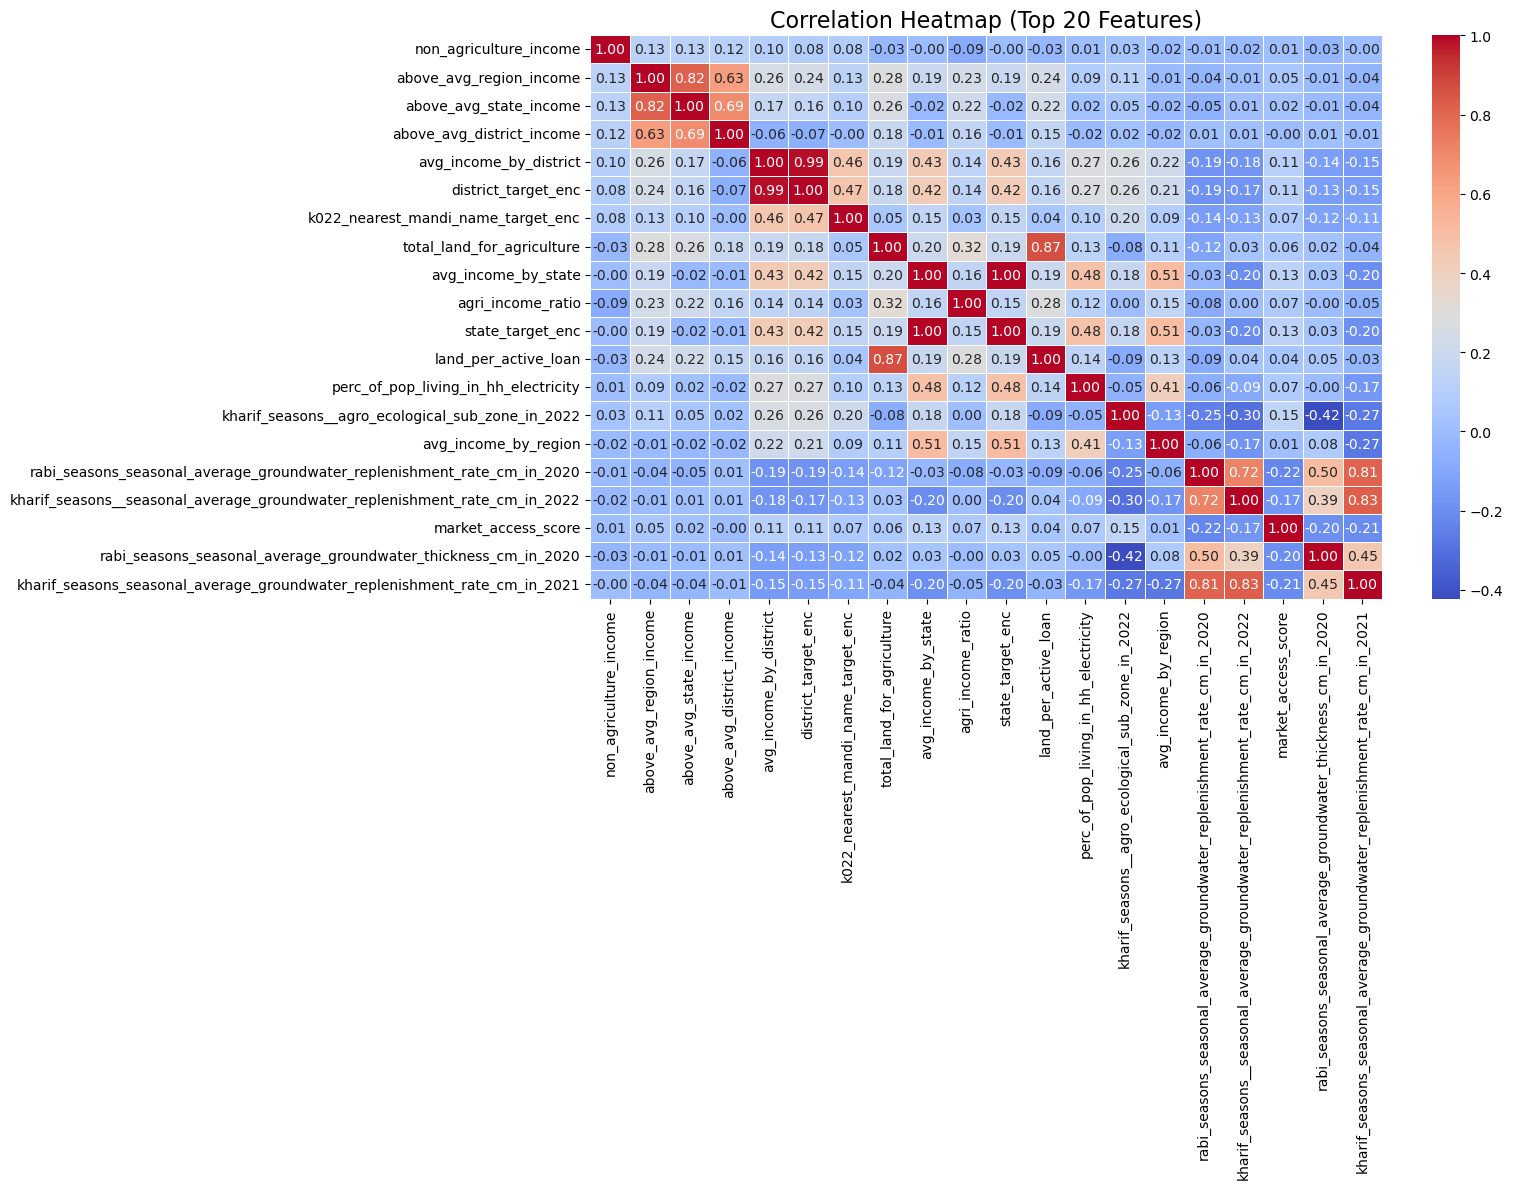

In [732]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr()

# 3. Select top N features most correlated with the target
target_corr = corr_matrix['target_variable_total_income'].abs().sort_values(ascending=False)
top_features = target_corr[1:21].index  # Exclude target itself and keep top 25

# 4. Filter correlation matrix to these features
filtered_corr = corr_matrix.loc[top_features, top_features]

# 5. Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (Top 20 Features)", fontsize=16)
plt.tight_layout()
plt.show()


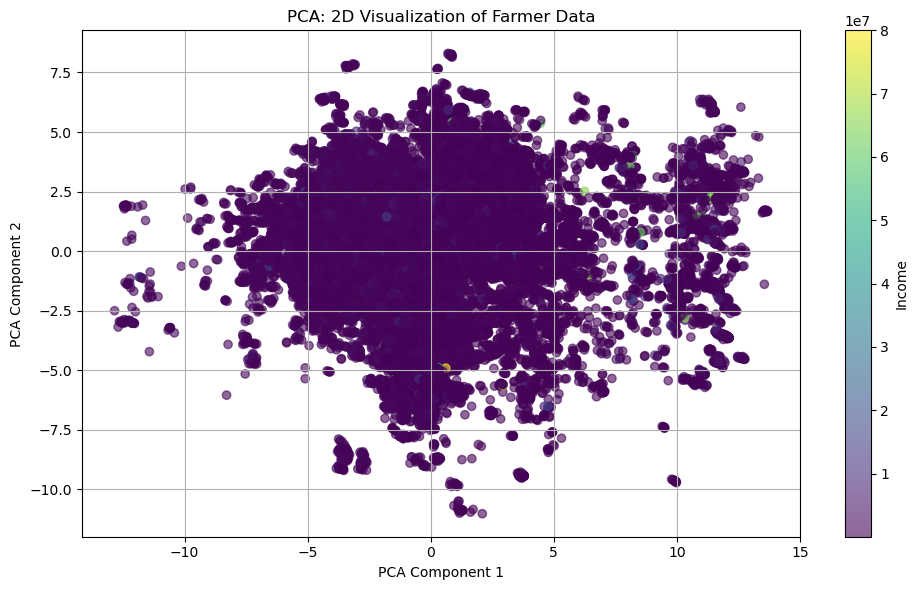

In [733]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Select only numeric features (excluding target + ID)
X_pca = df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
X_pca = X_pca.select_dtypes(include='number')

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca_components = pca.fit_transform(X_scaled)

# 4. Plot the PCA components
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca_components[:, 0],
    X_pca_components[:, 1],
    c=df['target_variable_total_income'],  # color by income
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA: 2D Visualization of Farmer Data")
cbar = plt.colorbar(scatter)
cbar.set_label("Income")
plt.grid(True)
plt.tight_layout()
plt.show()


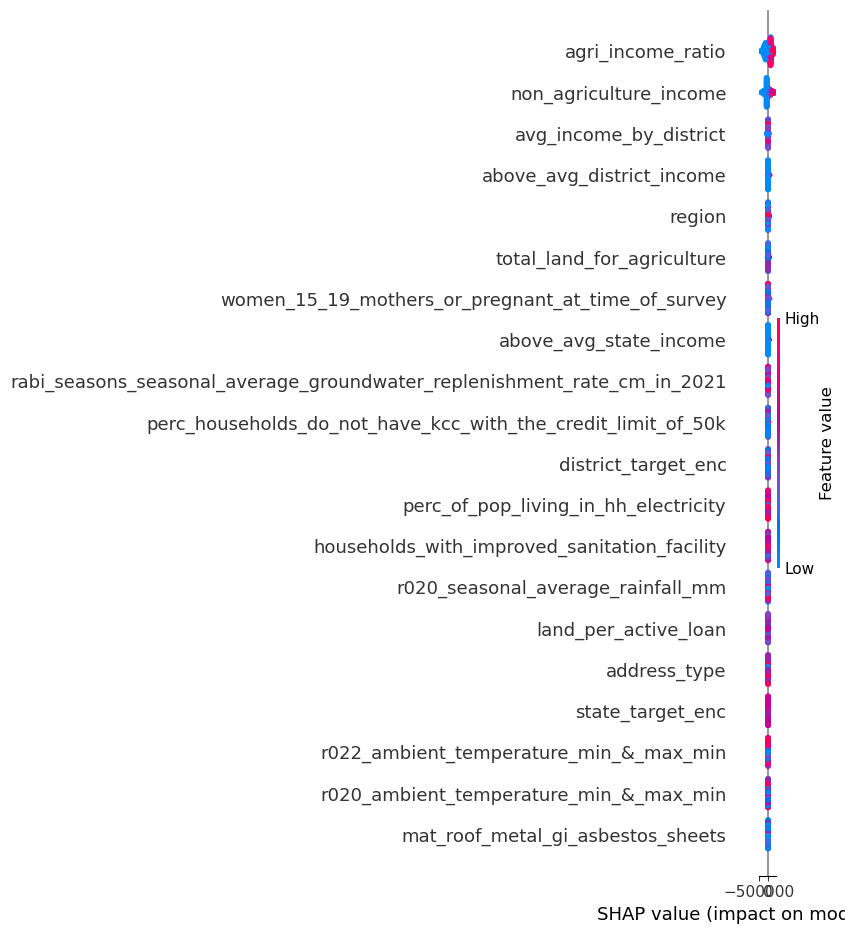

In [596]:
import shap

# Pick a trained model like xgb_low
model = xgb_low  # or xgb_mid / xgb_high

# Features used to train that segment
X_segment = df_low.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')

# Sample data for speed
X_sample = X_segment.sample(n=1000, random_state=42)

# Init SHAP
shap.initjs()

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Plot summary
shap.summary_plot(shap_values, X_sample)


# Applying it on Test file 

### (Moment of truth)

In [599]:
import pandas as pd
import numpy as np
import joblib
import pickle
from xgboost import XGBRegressor

# Load test data
df_test = pd.read_excel(
    r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx",
    sheet_name="TestData"
)

# Load models
model_low = joblib.load("xgb_low_final.pkl")
model_mid = joblib.load("xgb_mid_final.pkl")
model_high = joblib.load("xgb_high_final.pkl")

# Load encoders
label_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_agro_ecological_sub_zone_in_2020'
]
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

# Load target encoding maps and feature columns
target_maps = joblib.load("target_maps.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# -----------------------
# Preprocessing Function
# -----------------------
def preprocess(df_test):
    df_test = df_test.copy()
    
    # Handle missing values
    df_test.fillna(0, inplace=True)

    # Label Encoding with fallback for unknown values
    for col, encoder in label_encoders.items():
        if col in df_test.columns:
            known_classes = list(encoder.classes_)
            if 'Unknown' not in known_classes:
                encoder.classes_ = np.append(encoder.classes_, 'Unknown')
            df_test[col] = df_test[col].apply(lambda x: x if x in known_classes else 'Unknown')
            df_test[col] = encoder.transform(df_test[col])
        else:
            print(f"⚠️ Column missing for label encoding: {col}")

    # Target Encoding
    global_mean = np.mean([v for mapping in target_maps.values() for v in mapping.values()]) # fallback global mean
    for col, mapping in target_maps.items():
        if col in df_test.columns:
            df_test[col + '_target_enc'] = df_test[col].map(mapping)
            df_test[col + '_target_enc'] = df_test[col + '_target_enc'].fillna(global_mean)
        else:
            print(f"⚠️ Column missing for target encoding: {col}")

    # Feature Engineering
    df_test['land_per_active_loan'] = df_test.get('total_land_for_agriculture', 0) / (df_test.get('no_of_active_loan_in_bureau', 0) + 1)
    df_test['agri_income_ratio'] = df_test.get('non_agriculture_income', 0) / (df_test.get('target_variable_total_income', 1))

    # Drop original high-cardinality columns
    df_test.drop(columns=['district', 'state', 'k022_nearest_mandi_name'], errors='ignore', inplace=True)

    return df_test


In [609]:
# ===============================
# STEP 2: Clean & Standardize Column Names
# ===============================

def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

# Apply to all column names in df_test
df_test.columns = [clean_column(col) for col in df_test.columns]

# Preview cleaned column names
print("✅ Cleaned Column Names:\n")
print(df_test.columns.tolist()[:15])  # Show first 15 as a sample


✅ Cleaned Column Names:

['farmerid', 'state', 'region', 'sex', 'city', 'zipcode', 'district', 'village', 'marital_status', 'location', 'address_type', 'ownership', 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income']


In [611]:
# ===============================
# STEP 3: Handling Missing Values
# ===============================
df_test[['location', 'address_type', 'ownership']] = df_test[['location', 'address_type', 'ownership']].fillna("missing_info")

# Dealing with Avg Disbursement Amt, missing values

# Step 1: Create a binary flag indicating presence of bureau loan data
df_test['has_loan_bureau_data'] = df_test['avg_disbursement_amount_bureau'].notna().astype(int)

# Step 2: Replace missing values in Avg_Disbursement_Amount_Bureau with 0
df_test['avg_disbursement_amount_bureau'] = df_test['avg_disbursement_amount_bureau'].fillna(0)

# First, replace missing/None-like values with empty string
df_test['kharif_seasons__type_of_water_bodies_in_hectares_2022'] = df_test['kharif_seasons__type_of_water_bodies_in_hectares_2022'].fillna("").astype(str).str.lower()

# Define keywords to look for
keywords = ['river', 'water', 'reservoir', 'riverbank', 'wetland']

# Create binary columns for each keyword
for kw in keywords:
    df_test[f'near_{kw}'] = df_test['kharif_seasons__type_of_water_bodies_in_hectares_2022'].apply(lambda x: int(kw in x))

# Optional: Drop the original column
df_test.drop(columns=['kharif_seasons__type_of_water_bodies_in_hectares_2022'], inplace=True)

# Preview
df_test[[f'near_{kw}' for kw in keywords]].head()

# Replace with actual column names
temp_cols = [
    'k022_ambient_temperature_min_&_max',
    'r022_ambient_temperature_min_&_max',
    'k021_ambient_temperature_min_&_max',
    'r021_ambient_temperature_min_&_max',
    'r020_ambient_temperature_min_&_max'
]

for col in temp_cols:
    df_test[[f"{col}_min", f"{col}_max"]] = df_test[col].str.split('/', expand=True).astype(float)
df_test.drop(columns=temp_cols, inplace=True)

# Some engineered Features 
# ===============================
# 1. Relative Income Features
# ===============================
for geo in ['state', 'region', 'district']:
    avg_col = f'avg_income_by_{geo}'
    bin_col = f'above_avg_{geo}_income'

    df_test[avg_col] = df_test.groupby(geo)['target_variable_total_income'].transform('mean')
    df_test[bin_col] = (df_test['target_variable_total_income'] > df_test[avg_col]).astype(int)

# ===============================
# 2. Domain-Inspired Features
# ===============================

# Land-based
df_test['land_per_active_loan'] = df_test['total_land_for_agriculture'] / (df_test['no_of_active_loan_in_bureau'] + 1)
df_test['agri_income_ratio'] = df_test['target_variable_total_income'] / (df_test['non_agriculture_income'] + 1)

# Rainfall
rain_cols = [col for col in df_test.columns if 'rainfall_mm' in col]
df_test['avg_rainfall'] = df_test[rain_cols].mean(axis=1)

# Living conditions
df_test['housing_quality_score'] = (
    df_test['perc_of_house_with_6plus_room'] +
    df_test['perc_households_with_pucca_house_that_has_more_than_3_rooms'] +
    df_test['perc_of_pop_living_in_hh_electricity']
) / 3

# Groundwater
gw_cols = [col for col in df_test.columns if 'groundwater_thickness' in col]
df_test['groundwater_variability'] = df_test[gw_cols].std(axis=1)

# Market access
df_test['market_access_score'] = 1 / (df_test['k022_proximity_to_nearest_mandi_km'] + 1)
df_test['rail_access_score'] = 1 / (df_test['k022_proximity_to_nearest_railway_km'] + 1)

df_test.drop(columns=['district', 'k022_nearest_mandi_name', 'state'], inplace=True)


In [613]:
list(df_test.keys())

['farmerid',
 'region',
 'sex',
 'city',
 'zipcode',
 'village',
 'marital_status',
 'location',
 'address_type',
 'ownership',
 'no_of_active_loan_in_bureau',
 'avg_disbursement_amount_bureau',
 'non_agriculture_income',
 'total_land_for_agriculture',
 'k022_village_category_based_on_agri_parameters_good,_average,_poor',
 'k022_proximity_to_nearest_mandi_km',
 'k022_proximity_to_nearest_railway_km',
 'ko22_village_score_based_on_socio_economic_parameters_0_to_100',
 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor',
 'k022_seasonal_average_rainfall_mm',
 'r022_village_category_based_on_agri_parameters_good,_average,_poor',
 'r022_seasonal_average_rainfall_mm',
 'k021_seasonal_average_rainfall_mm',
 'r021_seasonal_average_rainfall_mm',
 'r020_seasonal_average_rainfall_mm',
 'perc_of_house_with_6plus_room',
 'women_15_19_mothers_or_pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh_electricity',
 'perc_households_with_pucca_house_that_has_more_than_3_ro

In [615]:
list(df.keys())

['farmerid',
 'region',
 'sex',
 'marital_status',
 'address_type',
 'ownership',
 'no_of_active_loan_in_bureau',
 'avg_disbursement_amount_bureau',
 'non_agriculture_income',
 'total_land_for_agriculture',
 'k022_proximity_to_nearest_mandi_km',
 'k022_proximity_to_nearest_railway_km',
 'ko22_village_score_based_on_socio_economic_parameters_0_to_100',
 'k022_seasonal_average_rainfall_mm',
 'r022_seasonal_average_rainfall_mm',
 'k021_seasonal_average_rainfall_mm',
 'r021_seasonal_average_rainfall_mm',
 'r020_seasonal_average_rainfall_mm',
 'perc_of_house_with_6plus_room',
 'women_15_19_mothers_or_pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh_electricity',
 'perc_households_with_pucca_house_that_has_more_than_3_rooms',
 'mat_roof_metal_gi_asbestos_sheets',
 'perc_of_wall_material_with_burnt_brick',
 'households_with_improved_sanitation_facility',
 'perc_households_do_not_have_kcc_with_the_credit_limit_of_50k',
 'k022_total_geographical_area_in_hectares_',
 'k022_net_agri_area_i

In [617]:
feature_columns = [col if col not in ['district', 'state', 'k022_nearest_mandi_name'] else col + '_target_enc' for col in feature_columns]

In [619]:
list(df.keys())

['farmerid',
 'region',
 'sex',
 'marital_status',
 'address_type',
 'ownership',
 'no_of_active_loan_in_bureau',
 'avg_disbursement_amount_bureau',
 'non_agriculture_income',
 'total_land_for_agriculture',
 'k022_proximity_to_nearest_mandi_km',
 'k022_proximity_to_nearest_railway_km',
 'ko22_village_score_based_on_socio_economic_parameters_0_to_100',
 'k022_seasonal_average_rainfall_mm',
 'r022_seasonal_average_rainfall_mm',
 'k021_seasonal_average_rainfall_mm',
 'r021_seasonal_average_rainfall_mm',
 'r020_seasonal_average_rainfall_mm',
 'perc_of_house_with_6plus_room',
 'women_15_19_mothers_or_pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh_electricity',
 'perc_households_with_pucca_house_that_has_more_than_3_rooms',
 'mat_roof_metal_gi_asbestos_sheets',
 'perc_of_wall_material_with_burnt_brick',
 'households_with_improved_sanitation_facility',
 'perc_households_do_not_have_kcc_with_the_credit_limit_of_50k',
 'k022_total_geographical_area_in_hectares_',
 'k022_net_agri_area_i

In [436]:
# 1. Handle missing values
df_test.fillna(0, inplace=True)

# 2. Label Encoding
for col, encoder in label_encoders.items():
    if col in df_test.columns:
        known_classes = list(encoder.classes_)
        if 'Unknown' not in known_classes:
            encoder.classes_ = np.append(encoder.classes_, 'Unknown')
        df_test[col] = df_test[col].apply(lambda x: x if x in known_classes else 'Unknown')
        df_test[col] = encoder.transform(df_test[col])
    else:
        print(f"⚠️ Column missing for label encoding: {col}")

# 3. Target Encoding
for col, mapping in target_maps.items():
    if col in df_test.columns:
        df_test[col + '_target_enc'] = df_test[col].map(mapping).fillna(np.mean(list(mapping.values())))
    else:
        print(f"⚠️ Column missing for target encoding: {col}")

# 4. Derived features (same as training)
df_test['land_per_active_loan'] = df_test['total_land_for_agriculture'] / (df_test['no_of_active_loan_in_bureau'] + 1)
df_test['agri_income_ratio'] = df_test['non_agriculture_income'] / (df_test['total_land_for_agriculture'] + 1)

rain_cols = [col for col in df_test.columns if 'rainfall_mm' in col]
df_test['avg_rainfall'] = df_test[rain_cols].mean(axis=1)

df_test['housing_quality_score'] = (
    df_test['perc_of_house_with_6plus_room'] +
    df_test['perc_households_with_pucca_house_that_has_more_than_3_rooms'] +
    df_test['perc_of_pop_living_in_hh_electricity']
) / 3

gw_cols = [col for col in df_test.columns if 'groundwater_thickness' in col]
df_test['groundwater_variability'] = df_test[gw_cols].std(axis=1)

df_test['market_access_score'] = 1 / (df_test['k022_proximity_to_nearest_mandi_km'] + 1)
df_test['rail_access_score'] = 1 / (df_test['k022_proximity_to_nearest_railway_km'] + 1)

# Relative Income Proxies
df_test['avg_income_by_state'] = df_test['state_target_enc'].map(
    df[['state_target_enc', 'avg_income_by_state']].drop_duplicates().set_index('state_target_enc')['avg_income_by_state']
)
df_test['above_avg_state_income'] = 0

df_test['avg_income_by_district'] = df_test['district_target_enc'].map(
    df[['district_target_enc', 'avg_income_by_district']].drop_duplicates().set_index('district_target_enc')['avg_income_by_district']
)
df_test['above_avg_district_income'] = 0

df_test['avg_income_by_region'] = df_test['region'].map(
    df[['region', 'avg_income_by_region']].drop_duplicates().set_index('region')['avg_income_by_region']
)
df_test['above_avg_region_income'] = 0

# Drop unused original high-cardinality cols
df_test.drop(columns=['district', 'state', 'k022_nearest_mandi_name'], errors='ignore', inplace=True)

return df_test


⚠️ Column missing for target encoding: district
⚠️ Column missing for target encoding: k022_nearest_mandi_name
⚠️ Column missing for target encoding: state


KeyError: 'state_target_enc'

In [621]:
# Apply preprocessing
df_test_processed = preprocess(df_test)

replacements = {
'state': 'state_target_enc',
'district': 'district_target_enc',
'k022_nearest_mandi_name': 'k022_nearest_mandi_name_target_enc'
}

feature_columns = [
    replacements.get(col, col)
    for col in feature_columns
        if replacements.get(col, col) in df_test_processed.columns
]

# Predict segment-wise
def segment_and_predict(df_test_processed, df_test_raw):
    # Use proxy segmentation logic (e.g., using engineered proxy or dummy threshold)
    # If you don’t have income in test set, base segmentation on proxy feature like land, assets, etc.

    df_test_processed['segment'] = 'mid'  # default all

    # Dummy logic: segment by land size (adjust if needed)
    df_test_processed.loc[df_test_processed['total_land_for_agriculture'] < 2, 'segment'] = 'low'
    df_test_processed.loc[df_test_processed['total_land_for_agriculture'] > 6, 'segment'] = 'high'

    predictions = []

    for seg_name, model in [('low', model_low), ('mid', model_mid), ('high', model_high)]:
        seg_df = df_test_processed[df_test_processed['segment'] == seg_name]
        if not seg_df.empty:
            X = seg_df[feature_columns]
            preds = model.predict(X)
            df_test_raw.loc[seg_df.index, 'Predicted_Income'] = preds

    return df_test_raw

# Predict and merge results
df_test_with_preds = segment_and_predict(df_test_processed, df_test)

# Save final results
df_test_with_preds.to_csv("test_predictions.csv", index=False)
print("✅ Predictions saved to test_predictions.csv")


AttributeError: 'numpy.ndarray' object has no attribute 'items'

In [438]:
import pandas as pd
import numpy as np
import joblib
import pickle
from xgboost import XGBRegressor

In [441]:
# STEP 1: Load Test Data and Artifacts
# ================================

df_test = pd.read_excel(
    r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx",
    sheet_name="TestData"
)

# Load models
model_low = joblib.load("xgb_low_final.pkl")
model_mid = joblib.load("xgb_mid_final.pkl")
model_high = joblib.load("xgb_high_final.pkl")

# Load encoders
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

# Load target encoding maps and feature columns
target_maps = joblib.load("target_maps.pkl")
feature_columns = joblib.load("feature_columns.pkl")


In [442]:
# STEP 2: Clean Column Names
# ================================
def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )
df_test.columns = [clean_column(col) for col in df_test.columns]

In [473]:
# STEP 3: Preprocessing Function
# ================================
def preprocess(df_test, df_train):
    df_test = df_test.copy()

    # Handle missing values
    df_test.fillna(0, inplace=True)
    
    # Label Encoding
    for col, encoder in label_encoders.items():
        if col in df_test.columns:
            known_classes = list(encoder.classes_)
            if 'Unknown' not in known_classes:
                encoder.classes_ = np.append(encoder.classes_, 'Unknown')
            df_test[col] = df_test[col].apply(lambda x: x if x in known_classes else 'Unknown')
            df_test[col] = encoder.transform(df_test[col])
        else:
            print(f"⚠️ Column missing for label encoding: {col}")
    
    # Target Encoding
    for col, mapping in target_maps.items():
        if col in df_test.columns:
            df_test[col + '_target_enc'] = df_test[col].map(mapping).fillna(np.mean(list(mapping.values())))
        else:
            print(f"⚠️ Column missing for target encoding: {col}")
    
    # Water body keywords
    df_test['kharif_seasons__type_of_water_bodies_in_hectares_2022'] = df_test['kharif_seasons__type_of_water_bodies_in_hectares_2022'].fillna("").astype(str).str.lower()
    for kw in ['river', 'water', 'reservoir', 'riverbank', 'wetland']:
        df_test[f'near_{kw}'] = df_test['kharif_seasons__type_of_water_bodies_in_hectares_2022'].apply(lambda x: int(kw in x))
    df_test.drop(columns=['kharif_seasons__type_of_water_bodies_in_hectares_2022'], inplace=True)
    
    # Split temperature columns
    temp_cols = [
        'k022_ambient_temperature_min_&_max',
        'r022_ambient_temperature_min_&_max',
        'k021_ambient_temperature_min_&_max',
        'r021_ambient_temperature_min_&_max',
        'r020_ambient_temperature_min_&_max'
    ]
    for col in temp_cols:
        df_test[[f"{col}_min", f"{col}_max"]] = df_test[col].str.split('/', expand=True).astype(float)
    df_test.drop(columns=temp_cols, inplace=True)
    
    # Engineered Features
    df_test['land_per_active_loan'] = df_test['total_land_for_agriculture'] / (df_test['no_of_active_loan_in_bureau'] + 1)
    df_test['agri_income_ratio'] = df_test['non_agriculture_income'] / (df_test['total_land_for_agriculture'] + 1)
    
    rain_cols = [col for col in df_test.columns if 'rainfall_mm' in col]
    df_test['avg_rainfall'] = df_test[rain_cols].mean(axis=1)
    
    df_test['housing_quality_score'] = (
        df_test['perc_of_house_with_6plus_room'] +
        df_test['perc_households_with_pucca_house_that_has_more_than_3_rooms'] +
        df_test['perc_of_pop_living_in_hh_electricity']
    ) / 3
    
    gw_cols = [col for col in df_test.columns if 'groundwater_thickness' in col]
    df_test['groundwater_variability'] = df_test[gw_cols].std(axis=1)
    
    df_test['market_access_score'] = 1 / (df_test['k022_proximity_to_nearest_mandi_km'] + 1)
    df_test['rail_access_score'] = 1 / (df_test['k022_proximity_to_nearest_railway_km'] + 1)

    df_test['has_loan_bureau_data'] = df_test['avg_disbursement_amount_bureau'].notna().astype(int)

    
    # Proxy Income Mapping using df_train
    for geo in ['state', 'region', 'district']:
        enc_col = geo + '_target_enc' if geo in ['state', 'district'] else geo
        avg_col = f'avg_income_by_{geo}'
        bin_col = f'above_avg_{geo}_income'
    
        if enc_col in df_test.columns and enc_col in df_train.columns and avg_col in df_train.columns:
            avg_map = df_train[[enc_col, avg_col]].drop_duplicates().set_index(enc_col)[avg_col]
            df_test[avg_col] = df_test[enc_col].map(avg_map).fillna(0)
            df_test[bin_col] = 0

    
    
    # Final cleanup
    df_test.drop(columns=['district', 'state', 'k022_nearest_mandi_name'], errors='ignore', inplace=True)
    
    return df_test


In [475]:
# STEP 4: Preprocess Test Data
# ================================
df_test_processed = preprocess(df_test, df)

# Replace encoded names in feature list
replacements = {
    'state': 'state_target_enc',
    'district': 'district_target_enc',
    'k022_nearest_mandi_name': 'k022_nearest_mandi_name_target_enc'
}

feature_columns = [replacements.get(col, col) for col in feature_columns if replacements.get(col, col) in df_test_processed.columns]


In [479]:
list(df_test_processed.keys())

['farmerid',
 'region',
 'sex',
 'city',
 'zipcode',
 'village',
 'marital_status',
 'location',
 'address_type',
 'ownership',
 'no_of_active_loan_in_bureau',
 'avg_disbursement_amount_bureau',
 'non_agriculture_income',
 'total_land_for_agriculture',
 'k022_village_category_based_on_agri_parameters_good,_average,_poor',
 'k022_proximity_to_nearest_mandi_km',
 'k022_proximity_to_nearest_railway_km',
 'ko22_village_score_based_on_socio_economic_parameters_0_to_100',
 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor',
 'k022_seasonal_average_rainfall_mm',
 'r022_village_category_based_on_agri_parameters_good,_average,_poor',
 'r022_seasonal_average_rainfall_mm',
 'k021_seasonal_average_rainfall_mm',
 'r021_seasonal_average_rainfall_mm',
 'r020_seasonal_average_rainfall_mm',
 'perc_of_house_with_6plus_room',
 'women_15_19_mothers_or_pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh_electricity',
 'perc_households_with_pucca_house_that_has_more_than_3_ro

In [467]:
def segment_and_predict(df_test_processed, df_test_raw):
    df_test_processed = df_test_processed.copy()
    df_test_raw = df_test_raw.copy()
    
    # Assign default segment
    df_test_processed['segment'] = 'mid'
    df_test_processed.loc[df_test_processed['total_land_for_agriculture'] < 2, 'segment'] = 'low'
    df_test_processed.loc[df_test_processed['total_land_for_agriculture'] > 6, 'segment'] = 'high'
    
    for seg_name, model in [('low', model_low), ('mid', model_mid), ('high', model_high)]:
        seg_df = df_test_processed[df_test_processed['segment'] == seg_name]
        if not seg_df.empty:
            X = seg_df[feature_columns]
            preds = model.predict(X)
            df_test_raw.loc[seg_df.index, 'Predicted_Income'] = preds
    
    return df_test_raw

df_test_with_preds = segment_and_predict(df_test_processed, df_test)

print("🔍 Sample Predictions:")
print(df_test_with_preds[['farmerid', 'Predicted_Income']].head())

print("\n📊 Prediction Summary Stats:")
print(df_test_with_preds['Predicted_Income'].describe())

print(f"\n✅ Total predictions made: {df_test_with_preds['Predicted_Income'].notna().sum()}")

df_test_with_preds.to_csv("test_predictions.csv", index=False)
print("\n💾 Predictions saved to test_predictions.csv")

ValueError: feature_names mismatch: ['region', 'sex', 'marital_status', 'address_type', 'ownership', 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income', 'total_land_for_agriculture', 'k022_proximity_to_nearest_mandi_km', 'k022_proximity_to_nearest_railway_km', 'ko22_village_score_based_on_socio_economic_parameters_0_to_100', 'k022_seasonal_average_rainfall_mm', 'r022_seasonal_average_rainfall_mm', 'k021_seasonal_average_rainfall_mm', 'r021_seasonal_average_rainfall_mm', 'r020_seasonal_average_rainfall_mm', 'perc_of_house_with_6plus_room', 'women_15_19_mothers_or_pregnant_at_time_of_survey', 'perc_of_pop_living_in_hh_electricity', 'perc_households_with_pucca_house_that_has_more_than_3_rooms', 'mat_roof_metal_gi_asbestos_sheets', 'perc_of_wall_material_with_burnt_brick', 'households_with_improved_sanitation_facility', 'perc_households_do_not_have_kcc_with_the_credit_limit_of_50k', 'k022_total_geographical_area_in_hectares_', 'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_', 'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022', 'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022', 'kharif_seasons__agro_ecological_sub_zone_in_2022', 'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022', 'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022', 'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021', 'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021', 'kharif_seasons_type_of_soil_in_2021', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020', 'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020', 'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'night_light_index', 'village_score_based_on_socio_economic_parameters_non_normalised', 'land_holding_index_source_total_agri_area__no_of_people', 'road_density_km__sqkm', 'has_loan_bureau_data', 'near_river', 'near_water', 'near_reservoir', 'near_riverbank', 'near_wetland', 'k022_ambient_temperature_min_&_max_min', 'k022_ambient_temperature_min_&_max_max', 'r022_ambient_temperature_min_&_max_min', 'r022_ambient_temperature_min_&_max_max', 'k021_ambient_temperature_min_&_max_min', 'k021_ambient_temperature_min_&_max_max', 'r021_ambient_temperature_min_&_max_min', 'r021_ambient_temperature_min_&_max_max', 'r020_ambient_temperature_min_&_max_min', 'r020_ambient_temperature_min_&_max_max', 'district_target_enc', 'k022_nearest_mandi_name_target_enc', 'state_target_enc', 'avg_income_by_state', 'above_avg_state_income', 'avg_income_by_region', 'above_avg_region_income', 'avg_income_by_district', 'above_avg_district_income', 'land_per_active_loan', 'agri_income_ratio', 'avg_rainfall', 'housing_quality_score', 'groundwater_variability', 'market_access_score', 'rail_access_score'] ['state_target_enc', 'region', 'sex', 'district_target_enc', 'marital_status', 'address_type', 'ownership', 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income', 'total_land_for_agriculture', 'k022_nearest_mandi_name_target_enc', 'k022_proximity_to_nearest_mandi_km', 'k022_proximity_to_nearest_railway_km', 'ko22_village_score_based_on_socio_economic_parameters_0_to_100', 'k022_seasonal_average_rainfall_mm', 'r022_seasonal_average_rainfall_mm', 'k021_seasonal_average_rainfall_mm', 'r021_seasonal_average_rainfall_mm', 'r020_seasonal_average_rainfall_mm', 'perc_of_house_with_6plus_room', 'women_15_19_mothers_or_pregnant_at_time_of_survey', 'perc_of_pop_living_in_hh_electricity', 'perc_households_with_pucca_house_that_has_more_than_3_rooms', 'mat_roof_metal_gi_asbestos_sheets', 'perc_of_wall_material_with_burnt_brick', 'households_with_improved_sanitation_facility', 'perc_households_do_not_have_kcc_with_the_credit_limit_of_50k', 'k022_total_geographical_area_in_hectares_', 'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_', 'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022', 'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022', 'kharif_seasons__agro_ecological_sub_zone_in_2022', 'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022', 'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022', 'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021', 'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021', 'kharif_seasons_type_of_soil_in_2021', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020', 'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020', 'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'night_light_index', 'village_score_based_on_socio_economic_parameters_non_normalised', 'land_holding_index_source_total_agri_area__no_of_people', 'road_density_km__sqkm', 'near_river', 'near_water', 'near_reservoir', 'near_riverbank', 'near_wetland', 'k022_ambient_temperature_min_&_max_min', 'k022_ambient_temperature_min_&_max_max', 'r022_ambient_temperature_min_&_max_min', 'r022_ambient_temperature_min_&_max_max', 'k021_ambient_temperature_min_&_max_min', 'k021_ambient_temperature_min_&_max_max', 'r021_ambient_temperature_min_&_max_min', 'r021_ambient_temperature_min_&_max_max', 'r020_ambient_temperature_min_&_max_min', 'r020_ambient_temperature_min_&_max_max']
expected rail_access_score, land_per_active_loan, agri_income_ratio, avg_rainfall, above_avg_district_income, above_avg_state_income, groundwater_variability, avg_income_by_district, avg_income_by_state, above_avg_region_income, avg_income_by_region, market_access_score, has_loan_bureau_data, housing_quality_score in input data

In [792]:
# ====================================================
# STEP 0: Imports
# ====================================================
import pandas as pd
import numpy as np
import joblib
import pickle
from sklearn.preprocessing import LabelEncoder

# ====================================================
# STEP 1: Load Test Data & Artifacts
# ====================================================
TEST_FILE = r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx"
MODEL_FILES = {
    'low': "xgb_low_final.pkl",
    'mid': "xgb_mid_final.pkl",
    'high': "xgb_high_final.pkl"
}
LABEL_ENCODERS_FILE = "label_encoders.pkl"
TARGET_MAPS_FILE = "target_maps.pkl"
FEATURE_COLUMNS_FILE = "feature_columns.pkl"

# Load test data
df_test = pd.read_excel(TEST_FILE, sheet_name="TestData")

# Load models
models = {seg: joblib.load(path) for seg, path in MODEL_FILES.items()}

# Load encoders with safety fix
with open(LABEL_ENCODERS_FILE, 'rb') as f:
    loaded_encoders = pickle.load(f)

if isinstance(loaded_encoders, dict):
    label_encoders = loaded_encoders
else:
    print("⚠️ Loaded encoders as array. Converting to dict...")
    label_cols = [
        'region', 'sex', 'marital_status', 'address_type', 
        'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
        'kharif_seasons_type_of_soil_in_2021'
    ]
    label_encoders = dict(zip(label_cols, loaded_encoders))

print(f"✅ Loaded {len(label_encoders)} label encoders.")


# Load target encoding maps and feature columns
target_maps = joblib.load(TARGET_MAPS_FILE)
feature_columns = joblib.load(FEATURE_COLUMNS_FILE)

print(f"✅ Test data shape: {df_test.shape}")
print(f"✅ Loaded {len(label_encoders)} label encoders.")

# ====================================================
# STEP 2: Utility Functions
# ====================================================
def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

def safe_split_temp_cols(df, temp_cols):
    for col in temp_cols:
        if col in df.columns:
            df[[f"{col}_min", f"{col}_max"]] = df[col].str.split('/', expand=True).astype(float)
    df.drop(columns=[c for c in temp_cols if c in df.columns], inplace=True)

def encode_labels(df):
    for col, encoder in label_encoders.items():
        if col in df.columns:
            known_classes = list(encoder.classes_)
            if 'Unknown' not in known_classes:
                encoder.classes_ = np.append(encoder.classes_, 'Unknown')
            df[col] = df[col].apply(lambda x: x if x in known_classes else 'Unknown')
            df[col] = encoder.transform(df[col])
    return df

def target_encode(df):
    for col, mapping in target_maps.items():
        if col in df.columns:
            df[col + '_target_enc'] = df[col].map(mapping).fillna(np.mean(list(mapping.values())))
    return df

# ====================================================
# STEP 3: Preprocessing
# ====================================================
def preprocess(df):
    df = df.copy()

    # 1️⃣ Clean column names
    df.columns = [clean_column(c) for c in df.columns]

    # 2️⃣ Basic missing handling
    df.fillna(0, inplace=True)

    # 3️⃣ Water body keywords
    water_col = next((c for c in df.columns if "type_of_water_bodies" in c), None)
    if water_col:
        df[water_col] = df[water_col].astype(str).str.lower()
        for kw in ['river', 'water', 'reservoir', 'riverbank', 'wetland']:
            df[f'near_{kw}'] = df[water_col].apply(lambda x: int(kw in x))
        df.drop(columns=[water_col], inplace=True)

    # 4️⃣ Split temperature cols
    temp_cols = [
        'k022_ambient_temperature_min_&_max',
        'r022_ambient_temperature_min_&_max',
        'k021_ambient_temperature_min_&_max',
        'r021_ambient_temperature_min_&_max',
        'r020_ambient_temperature_min_&_max'
    ]
    safe_split_temp_cols(df, temp_cols)

    # 5️⃣ Domain features
    if 'total_land_for_agriculture' in df.columns and 'no_of_active_loan_in_bureau' in df.columns:
        df['land_per_active_loan'] = df['total_land_for_agriculture'] / (df['no_of_active_loan_in_bureau'] + 1)

    if 'target_variable_total_income' in df.columns and 'non_agriculture_income' in df.columns:
        df['agri_income_ratio'] = df['target_variable_total_income'] / (df['non_agriculture_income'] + 1)

    rain_cols = [c for c in df.columns if 'rainfall_mm' in c]
    if rain_cols:
        df['avg_rainfall'] = df[rain_cols].mean(axis=1)

    living_cols = [
        'perc_of_house_with_6plus_room',
        'perc_households_with_pucca_house_that_has_more_than_3_rooms',
        'perc_of_pop_living_in_hh_electricity'
    ]
    if all(c in df.columns for c in living_cols):
        df['housing_quality_score'] = df[living_cols].mean(axis=1)

    gw_cols = [c for c in df.columns if 'groundwater_thickness' in c]
    if gw_cols:
        df['groundwater_variability'] = df[gw_cols].std(axis=1)

    if 'k022_proximity_to_nearest_mandi_km' in df.columns:
        df['market_access_score'] = 1 / (df['k022_proximity_to_nearest_mandi_km'] + 1)
    if 'k022_proximity_to_nearest_railway_km' in df.columns:
        df['rail_access_score'] = 1 / (df['k022_proximity_to_nearest_railway_km'] + 1)

    # 6️⃣ Encoding
    df = encode_labels(df)
    df = target_encode(df)

    # 7️⃣ Ensure all expected engineered columns exist
    expected_extra_cols = [
        'above_avg_district_income', 'above_avg_state_income', 'avg_income_by_district', 'avg_income_by_state',
        'above_avg_region_income', 'avg_income_by_region', 'has_loan_bureau_data'
    ]
    for col in expected_extra_cols:
        if col not in df.columns:
            df[col] = 0

    # 8️⃣ Final cleanup
    df.drop(columns=['district', 'state', 'k022_nearest_mandi_name'], errors='ignore', inplace=True)

    return df

df_test_processed = preprocess(df_test)
print(f"✅ Processed test shape: {df_test_processed.shape}")

# ====================================================
# STEP 4: Segment-wise Prediction
# ====================================================
def segment_and_predict(df_processed, df_raw):
    df_pred = df_raw.copy()
    df_processed['segment'] = 'mid'
    df_processed.loc[df_processed['total_land_for_agriculture'] < 2, 'segment'] = 'low'
    df_processed.loc[df_processed['total_land_for_agriculture'] > 6, 'segment'] = 'high'

    for seg, model in models.items():
        seg_df = df_processed[df_processed['segment'] == seg]
        if not seg_df.empty:
            X = seg_df[[col for col in feature_columns if col in seg_df.columns]]
            preds = model.predict(X)
            df_pred.loc[seg_df.index, 'Predicted_Income'] = preds

    return df_pred

df_test_with_preds = segment_and_predict(df_test_processed, df_test)

print("🔍 Sample Predictions:")
print(df_test_with_preds[['farmerid', 'Predicted_Income']].head())

df_test_with_preds.to_csv("test_predictions.csv", index=False)
print("💾 Predictions saved to test_predictions.csv")


⚠️ Loaded encoders as array. Converting to dict...
✅ Loaded 5 label encoders.
✅ Test data shape: (9986, 105)
✅ Loaded 5 label encoders.


AttributeError: 'str' object has no attribute 'classes_'